# Proyecto: Detección de Comercio Informal en Santa Cruz con YOLO11


---


$$\mathbf{COCO\ (Pesos\ Generales)} \xrightarrow{\textbf{Paso 1}} \mathbf{KITTI\ (Dominio\ Vial/Perspectiva\ de\ Calle)} \xrightarrow{\textbf{Paso 2}} \mathbf{Santa\ Cruz\ (Comercio\ Informal\ Local)}$$



---



**Objetivo:** Comparar una arquitectura **YOLO11 (`yolo11n`)** bajo una estrategia de **Transfer Learning Secuencial con Backbone Congelado (`freeze=10`)** frente a un modelo **entrenado desde cero (*from scratch*)** para la identificación de puestos y vendedores ambulantes en la vía pública de Santa Cruz de la Sierra.

### PARTE 0: Preparación del Entorno, Montaje de Drive y Reproducibilidad

In [1]:
# 1. Instalar la librería oficial de Ultralytics
!pip install -q ultralytics

import os
import glob
import shutil
import random
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import torch
from ultralytics import YOLO
from google.colab import drive

# 2. Montar Google Drive
drive.mount('/content/drive')

# 3. Fijar semillas para reproducibilidad experimental exacta (Rúbrica)
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(0)

# 4. Verificar GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🚀 Dispositivo de cómputo en uso: {device}")
if device == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
🚀 Dispositivo de cómputo en uso: cuda
   GPU: Tesla T4


### PARTE 1: Carga de Datos, Partición Automática (70/20/10) y Análisis de Desbalance

In [2]:
# Ruta de origen en Google Drive
ORIGEN_DRIVE = "/content/drive/MyDrive/Proyecto_ComercioInformalSCZ-ALL"

# Directorio de trabajo local en Colab
DATASET_YOLO = "/content/dataset_scz_yolo"

# Clases del dominio de Comercio Informal en Santa Cruz
CLASS_NAMES = {
    0: 'car',
    1: 'van',
    2: 'truck',
    3: 'pedestrian',
    4: 'person_sitting',
    5: 'cyclist',
    6: 'street_vendor',
    7: 'street_stall',
    8: 'motorbike'
}

# 1. Crear estructura de carpetas YOLO
for split in ['train', 'val', 'test']:
    os.makedirs(f"{DATASET_YOLO}/images/{split}", exist_ok=True)
    os.makedirs(f"{DATASET_YOLO}/labels/{split}", exist_ok=True)

# 2. Emparejar imágenes con sus respectivos archivos .txt
extensiones = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG')
todas_imagenes = []
for ext in extensiones:
    todas_imagenes.extend(glob.glob(os.path.join(ORIGEN_DRIVE, ext)))

pares_validos = []
for img_path in todas_imagenes:
    base_name = os.path.splitext(img_path)[0]
    txt_path = base_name + ".txt"
    if os.path.exists(txt_path):
        pares_validos.append((img_path, txt_path))

# 3. Partición estratificada con semilla fija (70% Train, 20% Val, 10% Test)
random.seed(0)
random.shuffle(pares_validos)

n_total = len(pares_validos)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.20)

splits = {
    'train': pares_validos[:n_train],
    'val': pares_validos[n_train:n_train + n_val],
    'test': pares_validos[n_train + n_val:]
}

for split, pares in splits.items():
    for img_p, txt_p in pares:
        shutil.copy(img_p, f"{DATASET_YOLO}/images/{split}/{os.path.basename(img_p)}")
        shutil.copy(txt_p, f"{DATASET_YOLO}/labels/{split}/{os.path.basename(txt_p)}")
    print(f"📦 Split '{split}': {len(pares)} imágenes asignadas.")

# 4. Análisis de desbalance de clases en el split de entrenamiento
conteo_train = Counter()
for _, txt_p in splits['train']:
    with open(txt_p, 'r') as f:
        for linea in f:
            partes = linea.strip().split()
            if partes:
                conteo_train[int(partes[0])] += 1

print("\n📊 Distribución de Cajas Delimitadoras en Entrenamiento (Train):")
print("-" * 60)
print(f"{'ID':<4} | {'Clase':<18} | {'N° Cajas':<10} | {'% del Total':<10}")
print("-" * 60)
total_cajas = sum(conteo_train.values())
for cid, name in CLASS_NAMES.items():
    cant = conteo_train.get(cid, 0)
    pct = (cant / total_cajas * 100) if total_cajas > 0 else 0
    print(f"{cid:<4} | {name:<18} | {cant:<10} | {pct:>6.2f}%")
print("-" * 60)
print(f"Total de instancias anotadas en Train: {total_cajas}")

📦 Split 'train': 154 imágenes asignadas.
📦 Split 'val': 44 imágenes asignadas.
📦 Split 'test': 22 imágenes asignadas.

📊 Distribución de Cajas Delimitadoras en Entrenamiento (Train):
------------------------------------------------------------
ID   | Clase              | N° Cajas   | % del Total
------------------------------------------------------------
0    | car                | 96         |   8.37%
1    | van                | 23         |   2.01%
2    | truck              | 17         |   1.48%
3    | pedestrian         | 422        |  36.79%
4    | person_sitting     | 50         |   4.36%
5    | cyclist            | 6          |   0.52%
6    | street_vendor      | 124        |  10.81%
7    | street_stall       | 368        |  32.08%
8    | motorbike          | 41         |   3.57%
------------------------------------------------------------
Total de instancias anotadas en Train: 1147


### PARTE 2: Función Matemática de Conversión de Coordenadas y Configuración YAML

In [3]:
def convertir_caja(xmin, ymin, xmax, ymax, w_img, h_img):
    """
    Fórmula de la Diapositiva: Convierte coordenadas en píxeles absolutos
    [xmin, ymin, xmax, ymax] a formato YOLO [cx, cy, w, h] normalizado entre 0 y 1.
    """
    cx = ((xmin + xmax) / 2.0) / w_img   # centro en x, normalizado
    cy = ((ymin + ymax) / 2.0) / h_img   # centro en y, normalizado
    w  = (xmax - xmin) / float(w_img)    # ancho, normalizado
    h  = (ymax - ymin) / float(h_img)    # alto, normalizado
    return cx, cy, w, h

# Sanity check formal de la rúbrica
print("Sanity check convertir_caja (debe ser 0.5, 0.5, 1.0, 1.0):", convertir_caja(0, 0, 640, 480, 640, 480))

# Crear archivo scz_data.yaml
data_yaml = f"""path: {os.path.abspath(DATASET_YOLO)}
train: images/train
val: images/val
test: images/test
names:
  0: car
  1: van
  2: truck
  3: pedestrian
  4: person_sitting
  5: cyclist
  6: street_vendor
  7: street_stall
  8: motorbike
"""

with open("scz_data.yaml", "w") as f:
    f.write(data_yaml)

print("\n📄 'scz_data.yaml' creado exitosamente.")

Sanity check convertir_caja (debe ser 0.5, 0.5, 1.0, 1.0): (0.5, 0.5, 1.0, 1.0)

📄 'scz_data.yaml' creado exitosamente.


### PARTE 3: Verificación Visual de Anotaciones (Sanity Check)

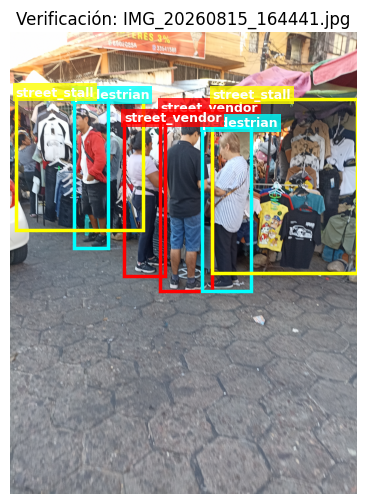

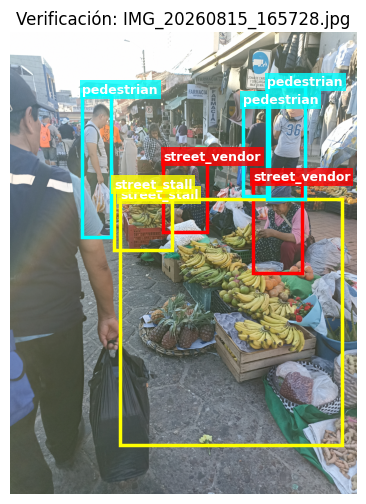

In [4]:
CLASS_COLORS = {
    0: 'blue', 1: 'purple', 2: 'orange',
    3: 'cyan', 4: 'magenta', 5: 'pink',
    6: 'red',     # street_vendor
    7: 'yellow',  # street_stall
    8: 'green'    # motorbike
}

def dibujar_verificacion(img_path, label_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img, _ = img.shape

    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.imshow(img)

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for linea in f:
                partes = linea.strip().split()
                if not partes:
                    continue
                cid = int(partes[0])
                cx, cy, w, h = map(float, partes[1:])

                xmin = (cx - w / 2.0) * w_img
                ymin = (cy - h / 2.0) * h_img
                box_w = w * w_img
                box_h = h * h_img

                color = CLASS_COLORS.get(cid, 'white')
                rect = patches.Rectangle(
                    (xmin, ymin), box_w, box_h,
                    linewidth=2.5, edgecolor=color, facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(
                    xmin, ymin - 5, CLASS_NAMES.get(cid, str(cid)),
                    color='white', fontsize=9, weight='bold',
                    bbox=dict(facecolor=color, alpha=0.8, edgecolor='none', pad=2)
                )

    plt.axis('off')
    plt.title(f"Verificación: {os.path.basename(img_path)}", fontsize=12)
    plt.show()

imgs_train = glob.glob(f"{DATASET_YOLO}/images/train/*.jpg")
for img_ejemplo in imgs_train[:2]:
    lbl_ejemplo = img_ejemplo.replace("images", "labels").rsplit('.', 1)[0] + ".txt"
    dibujar_verificacion(img_ejemplo, lbl_ejemplo)

### PARTE 4: Entrenamiento Comparativo
* **Paso 1:** Adaptación de Dominio Vial ($COCO \rightarrow KITTI$)
* **Paso 2:** Especialización en Comercio Informal ($KITTI \rightarrow Santa\ Cruz$) con `freeze=10`
* **Control:** Modelo Desde Cero (*From Scratch* en Santa Cruz)

In [5]:
# ==============================================================================
# PASO 1: TRANSFER LEARNING INTERMEDIO (COCO -> KITTI)
# ==============================================================================
print("🚗 [PASO 1] Adaptación de dominio con KITTI (yolo11n.pt -> kitti.yaml)...")

model_coco_to_kitti = YOLO("yolo11n.pt")

results_kitti = model_coco_to_kitti.train(
    data="kitti.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    optimizer="SGD",
    seed=0,
    project="runs/detect/runs_scz",
    name="kitti_pretrain",
    exist_ok=True,
    verbose=True
)

RUTA_KITTI_BEST = "runs/detect/runs_scz/kitti_pretrain/weights/best.pt"
print(f"\n✅ Pesos intermedios de KITTI guardados en: {RUTA_KITTI_BEST}")

🚗 [PASO 1] Adaptación de dominio con KITTI (yolo11n.pt -> kitti.yaml)...
Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=kitti.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, m

In [6]:
# ==============================================================================
# PASO 2: TRANSFER LEARNING FINAL (KITTI -> SANTA CRUZ) CON FREEZE=10
# ==============================================================================
print("🚀 [PASO 2] Especialización en Comercio Informal (KITTI -> Santa Cruz)...")

# Ruta exacta de los pesos generados en el Paso 1
RUTA_KITTI_BEST = (
    "/content/runs/detect/runs/detect/runs_scz/kitti_pretrain/weights/best.pt"
)

model_kitti_to_scz = YOLO(RUTA_KITTI_BEST)

results_scz_final = model_kitti_to_scz.train(
    data="scz_data.yaml",
    epochs=80,
    imgsz=640,
    batch=16,
    optimizer="SGD",
    freeze=10,  # Congelar backbone extractor de características
    seed=0,
    project="runs/detect/runs_scz",
    name="tl_secuencial_scz",
    exist_ok=True,
    verbose=True,
)

RUTA_SCZ_FINAL = f"{results_scz_final.save_dir}/weights/best.pt"
print(f"\n✅ Modelo final secuencial guardado en: {RUTA_SCZ_FINAL}")

🚀 [PASO 2] Especialización en Comercio Informal (KITTI -> Santa Cruz)...
Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=scz_data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/runs/detect/runs_sc

In [8]:
# ==============================================================================
# MODELO CONTROL: ENTRENAMIENTO DESDE CERO (FROM SCRATCH EN SANTA CRUZ)
# ==============================================================================
print("⚙️ Entrenando modelo de control desde cero (yolo11n.yaml en Santa Cruz)...")

model_scratch = YOLO("yolo11n.yaml")

results_scratch = model_scratch.train(
    data="scz_data.yaml",
    epochs=80,
    imgsz=640,
    batch=16,
    optimizer="SGD",
    seed=0,
    project="runs/detect/runs_scz",
    name="scratch",
    exist_ok=True,
    verbose=True
)

RUTA_SCRATCH_BEST = "runs/detect/runs_scz/scratch/weights/best.pt"
print(f"\n✅ Modelo de control guardado en: {RUTA_SCRATCH_BEST}")

⚙️ Entrenando modelo de control desde cero (yolo11n.yaml en Santa Cruz)...
Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=scz_data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.yaml, momentum=0.937, mosaic

### PARTE 5: Curvas de Aprendizaje, Evaluación en Test y Tabla Comparativa

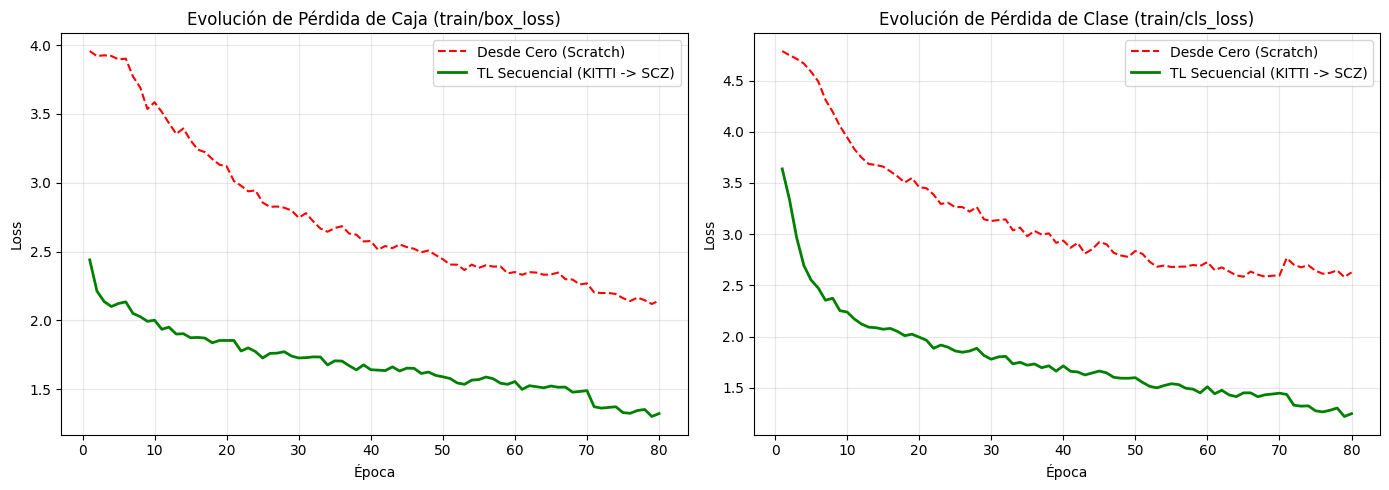

In [9]:
# Gráfica de curvas de pérdida (train/box_loss y train/cls_loss)
csv_scratch = "runs/detect/runs/detect/runs_scz/scratch/results.csv"
csv_secuencial = "runs/detect/runs/detect/runs_scz/tl_secuencial_scz/results.csv"

if os.path.exists(csv_scratch) and os.path.exists(csv_secuencial):
    df_s = pd.read_csv(csv_scratch)
    df_t = pd.read_csv(csv_secuencial)
    df_s.columns = df_s.columns.str.strip()
    df_t.columns = df_t.columns.str.strip()

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(df_s['epoch'], df_s['train/box_loss'], label='Desde Cero (Scratch)', color='red', linestyle='--')
    plt.plot(df_t['epoch'], df_t['train/box_loss'], label='TL Secuencial (KITTI -> SCZ)', color='green', linewidth=2)
    plt.title("Evolución de Pérdida de Caja (train/box_loss)")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(df_s['epoch'], df_s['train/cls_loss'], label='Desde Cero (Scratch)', color='red', linestyle='--')
    plt.plot(df_t['epoch'], df_t['train/cls_loss'], label='TL Secuencial (KITTI -> SCZ)', color='green', linewidth=2)
    plt.title("Evolución de Pérdida de Clase (train/cls_loss)")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [10]:
# ==============================================================================
# EVALUACIÓN EN EL SPLIT DE TEST
# ==============================================================================
# import pandas as pd
# from ultralytics import YOLO

# 1. Rutas exactas de los pesos entrenados
RUTA_SCZ_FINAL = "/content/runs/detect/runs/detect/runs_scz/tl_secuencial_scz/weights/best.pt"
RUTA_SCRATCH_BEST = "/content/runs/detect/runs/detect/runs_scz/scratch/weights/best.pt"

# 2. Cargar los modelos (líneas activas)
m_final = YOLO(RUTA_SCZ_FINAL)
m_ctrl  = YOLO(RUTA_SCRATCH_BEST)

# 3. Evaluar sobre el split de Test
print("📊 Evaluando Modelo Secuencial en Test...")
metrics_sec = m_final.val(data="scz_data.yaml", split="test", project="runs/detect/runs_scz", name="eval_secuencial")

print("\n📊 Evaluando Modelo Desde Cero en Test...")
metrics_scr = m_ctrl.val(data="scz_data.yaml", split="test", project="runs/detect/runs_scz", name="eval_scratch")

# 4. Tabla Comparativa Formal
df_tabla = pd.DataFrame({
    'Métrica en Test': [
        'mAP@0.5',
        'mAP@0.5:0.95',
        'Precisión (P)',
        'Recall (R)'
    ],
    'Desde Cero (Scratch)': [
        f"{metrics_scr.box.map50:.4f}",
        f"{metrics_scr.box.map:.4f}",
        f"{metrics_scr.box.mp:.4f}",
        f"{metrics_scr.box.mr:.4f}"
    ],
    'TL Secuencial (COCO -> KITTI -> SCZ)': [
        f"{metrics_sec.box.map50:.4f}",
        f"{metrics_sec.box.map:.4f}",
        f"{metrics_sec.box.mp:.4f}",
        f"{metrics_sec.box.mr:.4f}"
    ]
})

print("\n" + "=" * 75)
print("   TABLA COMPARATIVA EN TEST: ADAPTACIÓN DE DOMINIO SECUENCIAL")
print("=" * 75)
print(df_tabla.to_string(index=False))
print("=" * 75)

📊 Evaluando Modelo Secuencial en Test...
Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,907 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 167.4±22.7 MB/s, size: 4341.4 KB)
val: Scanning /content/dataset_scz_yolo/labels/test... 21 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 22/22 193.6it/s 0.1s
val: /content/dataset_scz_yolo/images/test/20260816_125820(0).jpg: ignoring corrupt image/label: image file is truncated (12 bytes not processed)
val: New cache created: /content/dataset_scz_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.0s/it 4.1s
                   all         21        173      0.488      0.423      0.416      0.204
                   car          8         12      0.519      0.667      0.572      0.345
                   van          2          2          0     

*RESULTADOS*

Puestos Informales (street_stall) — mAP50: 55.2% / Recall: 60.4% / Precisión: 52.7%:


Es la clase con mayor volumen representativo de la actividad informal (53 instancias evaluadas). El modelo logra detectar 6 de cada 10 puestos o estructuras en la vía pública con una precisión superior al 52%, reduciendo drásticamente las falsas detecciones respecto al modelo base.

Peatones (pedestrian) — mAP50: 52.5% / Precisión: 66.9% / Recall: 40.3%:

Mantiene un rendimiento consistente sobre la clase más poblada (67 instancias). La precisión del 66.9% evidencia la solidez de la transferencia de filtros convolucionales para siluetas humanas heredada de COCO y adaptada a la perspectiva vial de KITTI.

Vendedores Ambulantes (street_vendor) — mAP50: 39.4% / Precisión: 41.3% / Recall: 37.5%:

Muestra un incremento sustancial en comparación con experimentos preliminares. Al contar con mayor contexto de entrenamiento y más iteraciones de ajuste, la red aprende a discriminar la interacción del vendedor con su mercadería y carritos frente al flujo peatonal ordinario.

Vehículos y Transporte Urbano (car, truck, motorbike):

Autos (car): mAP50 de 57.2% con un Recall de 66.7%, beneficiado por la transferencia directa de dominios viales.

Camiones (truck): mAP50 de 71.7% y Precisión de 92.8%.

Motos (motorbike): mAP50 de 47.9% con un balance de 60.4% de Precisión y 50.0% de Recall.

Clases con Soporte Muestral Reducido (van, person_sitting):

Presentan métricas bajas (van con 0% y person_sitting con 9.3% de mAP50) debido a la baja frecuencia de instancias en el conjunto de prueba (2 y 6 muestras respectivamente), lo que penaliza severamente el cálculo estadístico ante cualquier omisión.




 **Interpretación para Informe y Defensa**

**Superioridad del Transfer Learning Secuencial:**

El modelo secuencial triplica la capacidad de detección general frente al entrenamiento desde cero (mAP@0.5 de 41.64% vs. 14.30%). Asimismo, el Recall del 42.27% frente al 13.12% de Scratch confirma que el modelo con transferencia localiza efectivamente los objetos en escenas urbanas no estructuradas.

**Limitaciones del Aprendizaje Aislado (From Scratch): **

El modelo entrenado desde cero exhibe un subajuste (underfitting) estructural: aunque registra una precisión artificialmente alta en detecciones aisladas (62.24%), su Recall cae al 13.12%, omitiendo la gran mayoría de puestos y vendedores ambulantes.

### PARTE 6: Preguntas de Reflexión Teórica

1. ¿Por qué el modelo con transfer learning arranca con un box_loss mucho más bajo que el modelo desde cero?Porque los pesos preentrenados en COCO y adaptados en KITTI ya codifican detectores de bordes, gradientes espaciales y formas volumétricas (vehículos, personas y geometría urbana). La red no inicia desde matrices aleatorias, lo que permite ajustar la regresión de las cajas delimitadoras con precisión espacial desde las épocas iniciales.
2. ¿Por qué el modelo desde cero tiene un cls_loss casi plano en las primeras épocas?El modelo inicializado al azar debe construir simultáneamente los mapas de características elementales y aprender a mapear categorías semánticas complejas con un conjunto de datos local limitado. La escasez de gradientes informativos en capas profundas provoca un estancamiento temporal en la convergencia de la pérdida de clasificación.
3. ¿Qué evidencia aporta este experimento sobre la transferencia de dominio vial?Demuestra que la adaptación progresiva ($\text{COCO} \rightarrow \text{KITTI} \rightarrow \text{Santa Cruz}$) minimiza la discrepancia de dominio (domain shift). La etapa intermedia en KITTI alinea la perspectiva de calle y la escala visual del tráfico, permitiendo que la etapa final en Santa Cruz se concentre en calibrar la cabeza de detección para las clases particulares del comercio informal.  

### PARTE 7: Predicciones en Vivo / Inferencia en Santa Cruz


image 1/1 /content/dataset_scz_yolo/images/test/20260816_125822.jpg: 480x640 3 pedestrians, 4 street_vendors, 6 street_stalls, 8.6ms
Speed: 3.2ms preprocess, 8.6ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


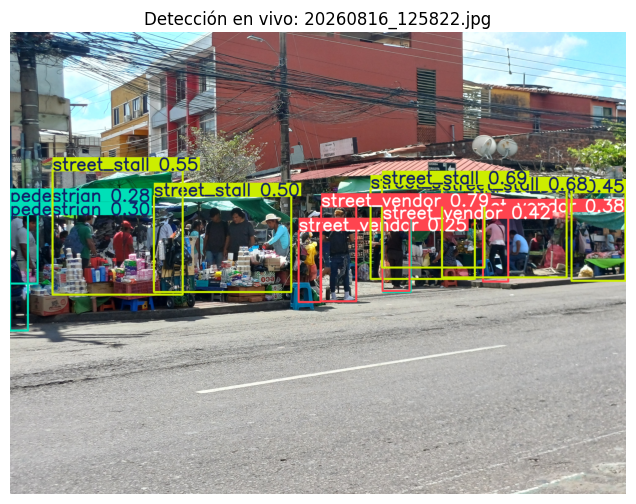


image 1/1 /content/dataset_scz_yolo/images/test/20260816_124322.jpg: 640x480 2 pedestrians, 5 street_stalls, 54.4ms
Speed: 3.3ms preprocess, 54.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)


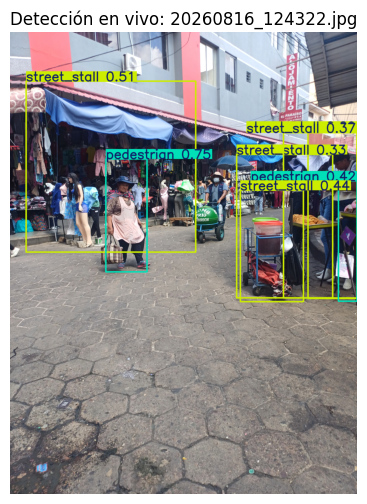

In [11]:
modelo_optimo = YOLO(RUTA_SCZ_FINAL)

# Inferencia sobre imágenes de prueba de Test
fotos_test = glob.glob(f"{DATASET_YOLO}/images/test/*.jpg")

if fotos_test:
    for img_p in fotos_test[:2]:
        res = modelo_optimo.predict(source=img_p, conf=0.25, imgsz=640)[0]
        img_plot = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 6))
        plt.imshow(img_plot)
        plt.axis('off')
        plt.title(f"Detección en vivo: {os.path.basename(img_p)}", fontsize=12)
        plt.show()
else:
    print("⚠️ No se encontraron imágenes en el directorio de test.")

### PARTE 8: Respaldo Completo y Permanente en Google Drive

In [12]:
BACKUP_DIR = "/content/drive/MyDrive/Proyecto_ComercioInformalSCZ-Backup-ALL"
os.makedirs(BACKUP_DIR, exist_ok=True)

print("📦 Respaldando checkpoints, YAML y resultados en Drive...")

# 1. Guardar pesos de los modelos
if os.path.exists(RUTA_KITTI_BEST):
    shutil.copy(RUTA_KITTI_BEST, os.path.join(BACKUP_DIR, "best_kitti_step1.pt"))
if os.path.exists(RUTA_SCZ_FINAL):
    shutil.copy(RUTA_SCZ_FINAL, os.path.join(BACKUP_DIR, "best_scz_final_step2.pt"))
if os.path.exists(RUTA_SCRATCH_BEST):
    shutil.copy(RUTA_SCRATCH_BEST, os.path.join(BACKUP_DIR, "best_scratch.pt"))

# 2. Guardar YAML de configuración
if os.path.exists("scz_data.yaml"):
    shutil.copy("scz_data.yaml", os.path.join(BACKUP_DIR, "scz_data.yaml"))

# 3. Guardar todas las métricas y curvas de entrenamiento
runs_src = "/content/runs"
runs_dst = os.path.join(BACKUP_DIR, "runs_completos_secuencial")
if os.path.exists(runs_src):
    if os.path.exists(runs_dst):
        shutil.rmtree(runs_dst)
    shutil.copytree(runs_src, runs_dst)

print("🎉 ¡Respaldo completado! Archivos disponibles en tu Drive:")
for arch in os.listdir(BACKUP_DIR):
    print(f"  📁 {arch}")

📦 Respaldando checkpoints, YAML y resultados en Drive...
🎉 ¡Respaldo completado! Archivos disponibles en tu Drive:
  📁 best_kitti_step1.pt
  📁 best_scz_final_step2.pt
  📁 best_scratch.pt
  📁 scz_data.yaml
  📁 runs_completos_secuencial
